In [66]:
## imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
## import dataset

df = pd.read_csv("../data/machine_failure_dataset_cleaned.csv")

# **ANALYSING, CLEANING & EDA**

ANALYSIS

In [68]:
df.head()

,product_ID,product_type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,power_failure,overstrain_failure
0,H29424,H,298.4,308.9,1782.0,23.9,24,0,0,0,0
1,H29425,H,298.6,309.1,1423.0,44.3,29,0,0,0,0
2,H29432,H,298.8,309.2,1306.0,54.5,50,0,0,0,0
3,H29434,H,298.9,309.3,1375.0,42.7,58,0,0,0,0
4,H29441,H,299.1,309.4,1811.0,24.6,77,0,0,0,0


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_ID             1081 non-null   str    
 1   product_type           1081 non-null   str    
 2   air_temperature_k      1072 non-null   float64
 3   process_temperature_k  1075 non-null   float64
 4   rotational_speed_rpm   1080 non-null   float64
 5   torque_nm              1074 non-null   float64
 6   tool_wear_min          1081 non-null   int64  
 7   machine_failure        1081 non-null   int64  
 8   tool_wear_failure      1081 non-null   int64  
 9   power_failure          1081 non-null   int64  
 10  overstrain_failure     1081 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 93.0 KB


In [70]:
df.describe()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,power_failure,overstrain_failure
count,1072.000000,1075.000000,1080.000000,1074.000000,1081.000000,1081.000000,1081.000000,1081.000000,1081.000000
mean,297.426679,308.288744,1539.454630,41.476164,108.653099,0.022202,0.000925,0.012951,0.009251
std,0.940060,0.976013,181.580554,29.685232,63.557417,0.147407,0.030415,0.113115,0.095779
min,295.300000,305.700000,1168.000000,4.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,296.800000,307.800000,1424.750000,33.200000,54.000000,0.000000,0.000000,0.000000,0.000000
50%,297.500000,308.400000,1503.000000,40.100000,110.000000,0.000000,0.000000,0.000000,0.000000
75%,298.100000,309.000000,1611.000000,46.475000,163.000000,0.000000,0.000000,0.000000,0.000000
max,299.100000,310.200000,2874.000000,500.000000,240.000000,1.000000,1.000000,1.000000,1.000000


In [71]:
df.shape

(1081, 11)

In [72]:
df.columns

Index(['product_ID', 'product_type', 'air_temperature_k',
       'process_temperature_k', 'rotational_speed_rpm', 'torque_nm',
       'tool_wear_min', 'machine_failure', 'tool_wear_failure',
       'power_failure', 'overstrain_failure'],
      dtype='str')

In [73]:
## Pipeline (Simple imputer) will deal with null values

df.isnull().sum()

product_ID               0
product_type             0
air_temperature_k        9
process_temperature_k    6
rotational_speed_rpm     1
torque_nm                7
tool_wear_min            0
machine_failure          0
tool_wear_failure        0
power_failure            0
overstrain_failure       0
dtype: int64

CLEANING

In [74]:
## removing unwanted columns

df = df.drop("product_ID", axis=1)

FEATURE ORGANIZATION

In [75]:
## defining target columns
target_columns = ["tool_wear_failure", "power_failure", "overstrain_failure"]
y = df[target_columns]

In [76]:
df[target_columns].value_counts()

tool_wear_failure  power_failure  overstrain_failure
0                  0              0                     1057
                   1              0                       13
                   0              1                        9
                   1              1                        1
1                  0              0                        1
Name: count, dtype: int64

In [77]:
print(y.head())

   tool_wear_failure  power_failure  overstrain_failure
0                  0              0                   0
1                  0              0                   0
2                  0              0                   0
3                  0              0                   0
4                  0              0                   0


In [78]:
## separating numerical and categorical


numerical_columns = ["air_temperature_k",
                     "process_temperature_k",
                     "rotational_speed_rpm",
                     "torque_nm",
                     "tool_wear_min"
                     

]
categorical_columns = [
                        "product_type",
]

EXPORATORY DATA ANALYSIS

DISTRIBUTION 
- help up understand how the data is distributed

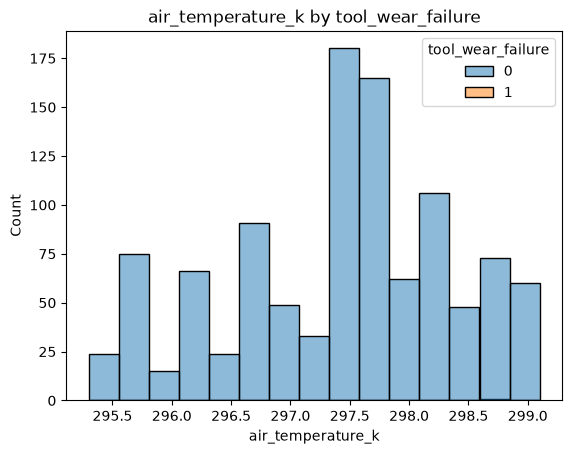

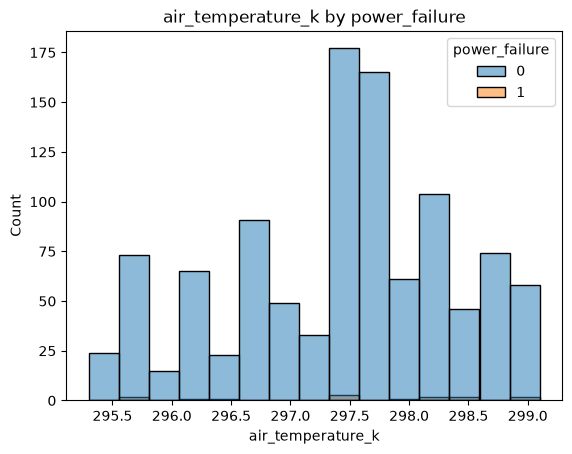

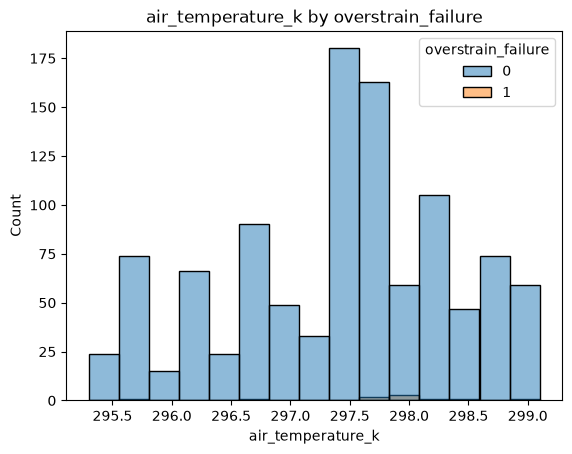

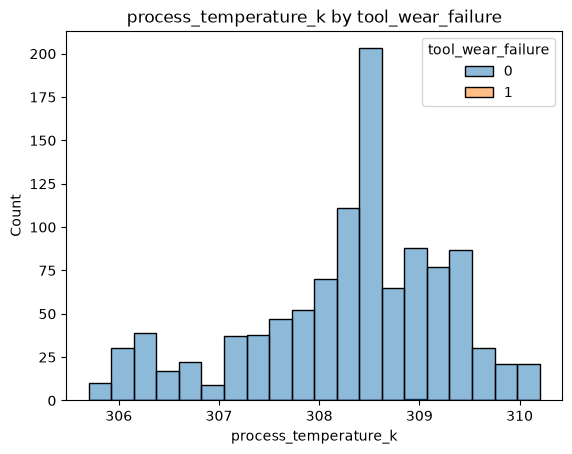

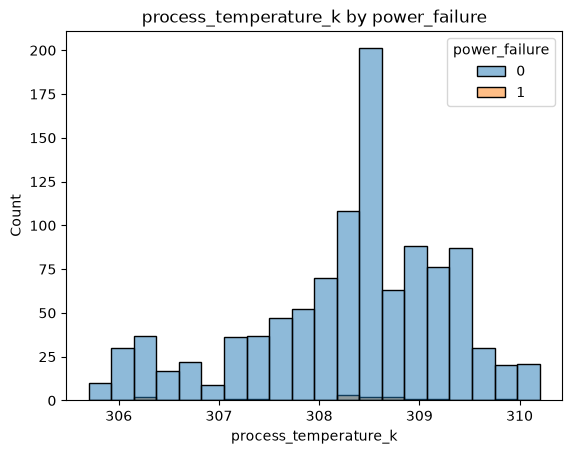

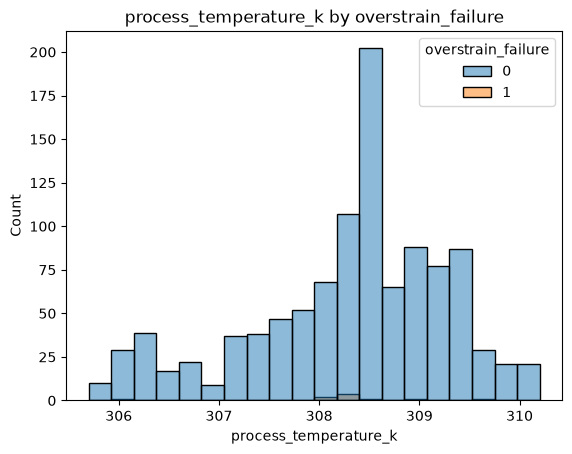

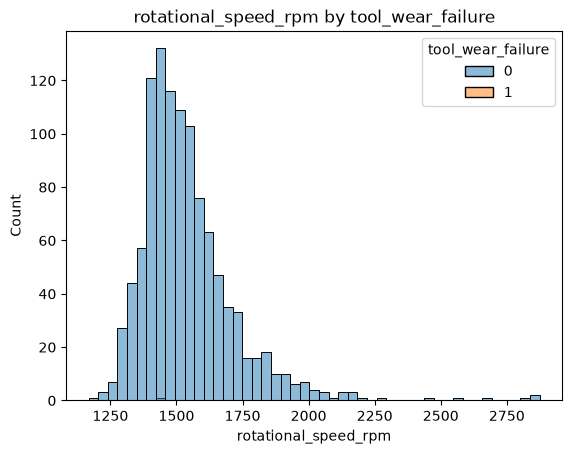

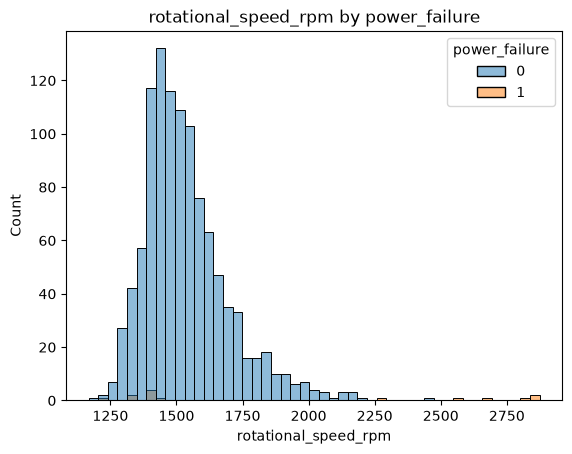

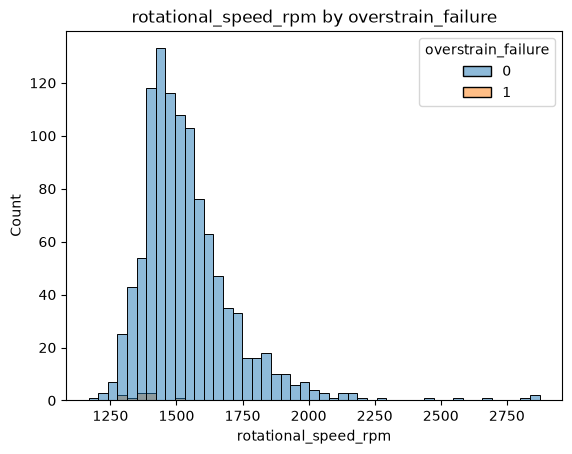

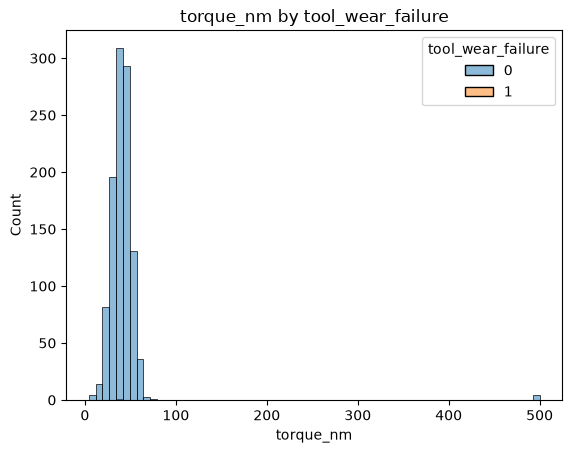

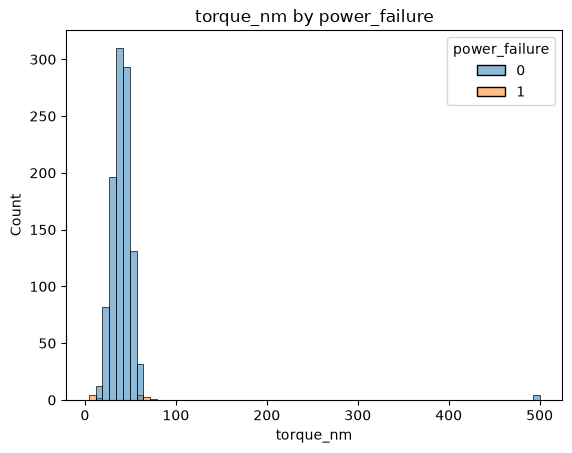

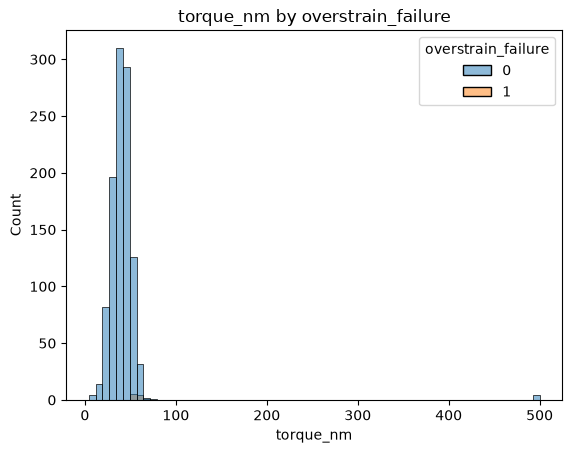

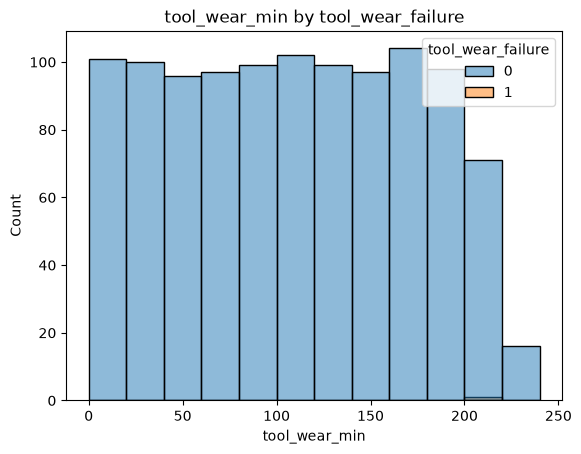

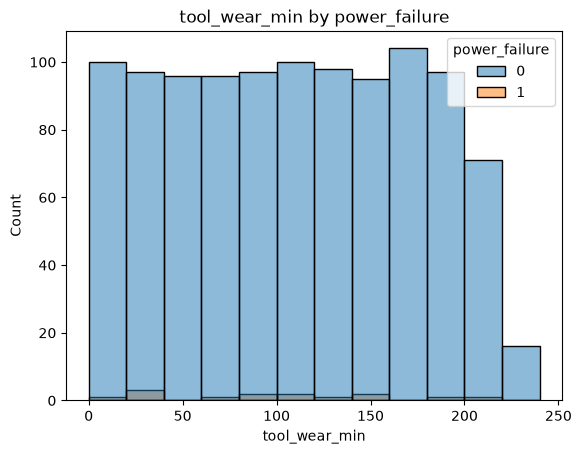

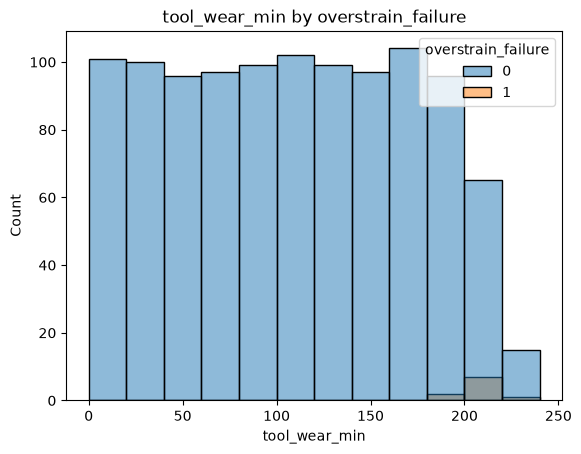

In [ ]:
## Histogram for numerical values
## distribution of each feature by each machine_failure_type

for column in numerical_columns:
    for target in target_columns:
        plt.figure()

        sns.histplot(
        data=df,
        x=column,
        hue=target
        )
        plt.title(
            f"{column} by {target}"
        )
        

Observation:

- air_temperature_k: shows a multimodal shape and tool_wear_failure is rare, a very small percentage of power_failure scattered along the distribution, and a smaller percentage of overstrain_failure between 297.5 K and 298.3 K.
  
- process_temperature_k: multimodal and left-skewed, tool_wear_failure is rare, a few power_failures are observed between 306 K and 310 K and a few overstrain_failures are observed between 307 K and 310 K. 
  
- rotational_speed_rpm: right skewed with a few outliers, a few tool_wear_failure observed where rotational_speed_rpm count is the highest, a few power_failures scattered along the distribution, a few overstrain_failures are observed between 1250 RPM and 1550 RPM.

- torque_nm: bell shape, left skewed a little bit, tool_wear_failures are rare, a small percentage of power_failures are observed from around 5 N.M to 25 N.M and around 60 N.M to 80 N.M, a few overstrain_failures observed where torque is more than (around) 50 N.M

- tool_wear_min: rectangle shape, right skewed a little, tool_wear_failures are rare however there are a few observed between 200 min to 225 min, part of the few power_failures are scattered along the distribution and a few overstrain_failures are scattered from around 175 min to 245 min.